● Lección 1: LA RED NEURONAL ARTIFICIAL

📌 Objetivo: Comprender los elementos de una red neuronal artifi cial y su rol en la resolución de problemas.

📍 Tareas a desarrollar:

● Defi nir la arquitectura de una red neuronal densa.

● Implementar una red neuronal simple para clasifi cación binaria.

● Identifi car capas, pesos, funciones de activación y pérdida.

In [1]:
#data con keras
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [4]:
print(X_train.shape)

(60000, 28, 28)


In [6]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

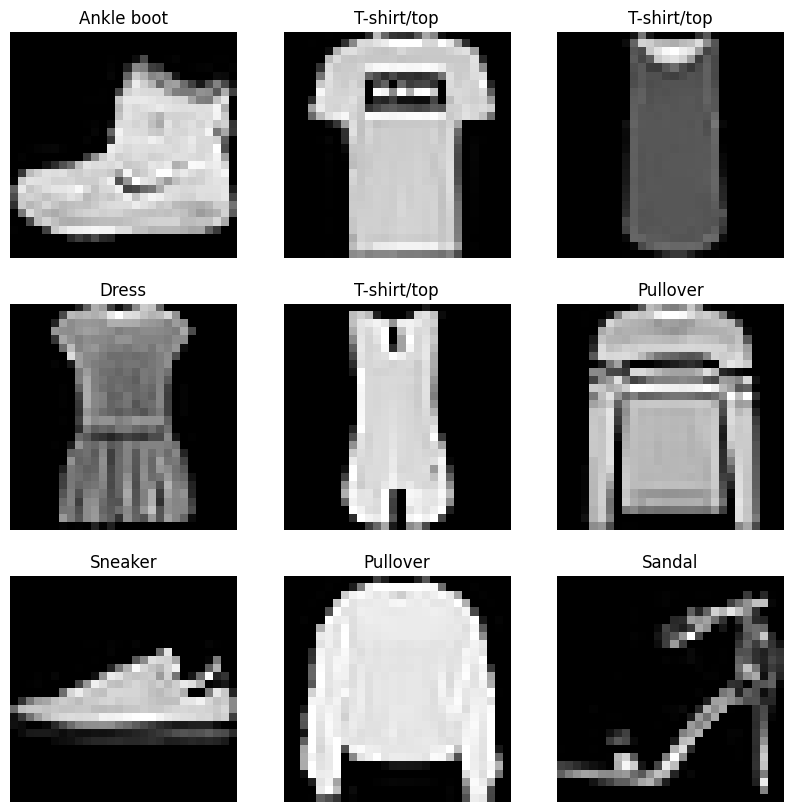

In [8]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [9]:
#Arquitectura básica (densa)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Definición del modelo (arquitectura de la red neuronal)
model = Sequential([

    # 🔹 CAPA DE ENTRADA (implícita) + PREPROCESAMIENTO
    # Convierte la imagen 28x28 en un vector de 784 valores
    Flatten(input_shape=(28,28)),

    # 🔹 CAPA OCULTA (Hidden Layer)
    # 128 neuronas
    # Cada neurona tiene PESOS y un sesgo (bias) que se ajustan en el entrenamiento
    # Función de activación: ReLU (permite aprender relaciones no lineales)
    Dense(128, activation='relu'),

    # 🔹 CAPA DE SALIDA (Output Layer)
    # 10 neuronas → una por cada clase de ropa
    # Función de activación: Softmax (convierte la salida en probabilidades)
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# Compilación del modelo
model.compile(
    optimizer='adam',  # 🔹 Optimizador: ajusta los PESOS automáticamente
    loss='sparse_categorical_crossentropy',  # 🔹 FUNCIÓN DE PÉRDIDA
    metrics=['accuracy']  # 🔹 Métrica de evaluación
)
"""
✔ Capas
Flatten: transforma la imagen en vector
Dense (128): capa oculta que aprende patrones
Dense (10): capa de salida para clasificación
✔ Pesos
Son parámetros internos de cada neurona
Se ajustan automáticamente durante el entrenamiento
✔ Funciones de activación
ReLU: usada en la capa oculta
Softmax: usada en la salida para obtener probabilidades
✔ Función de pérdida
sparse_categorical_crossentropy
Mide qué tan equivocadas son las predicciones del modelo
"""

Lección 2: Deep Learning
📌 Arquitectura óptima para clasificación de imágenes

Para problemas de clasificación de imágenes, la arquitectura más adecuada es una Red Neuronal Convolutiva (CNN, Convolutional Neural Network).

Las CNN están diseñadas específicamente para procesar datos con estructura espacial, como las imágenes. A diferencia de las redes densas, estas redes utilizan capas convolucionales que permiten detectar patrones locales como bordes, texturas y formas.

🔍 Características principales de una CNN:
Capas convolucionales (Conv2D): extraen características relevantes de la imagen.
Capas de pooling (MaxPooling): reducen la dimensionalidad y ayudan a generalizar.
Capas densas (Fully Connected): realizan la clasificación final.
Preservación de la estructura espacial: mantiene la relación entre píxeles cercanos.

👉 Por estas razones, las CNN son el estándar en tareas de visión computacional.

⚖️ Comparación: Red densa vs Red convolutiva
🔹 Red Neuronal Densa (ANN)

Ventajas:

Fácil de implementar
Menor costo computacional inicial
Útil para datos tabulares

Desventajas:

No considera la estructura espacial de la imagen
Mayor cantidad de parámetros (menos eficiente)
Menor precisión en imágenes
🔹 Red Neuronal Convolutiva (CNN)

Ventajas:

Detecta patrones espaciales (bordes, formas)
Menor cantidad de parámetros gracias a convoluciones
Mayor precisión en clasificación de imágenes

Desventajas:

Más compleja de implementar
Mayor tiempo de entrenamiento
Requiere mayor capacidad computacional
✅ Justificación de la elección

Para este proyecto, se utilizarán ambas arquitecturas:

Red densa: como modelo base (baseline), para comprender el comportamiento inicial.
CNN: como modelo optimizado, ya que permite mejorar significativamente la precisión al trabajar con imágenes.

Las redes convolutivas son más adecuadas para clasificación de imágenes debido a su capacidad de extraer características espaciales relevantes, lo que mejora el rendimiento del modelo frente a redes densas tradicionales

Selección del framework

Se selecciona Keras (TensorFlow) como framework principal para el desarrollo del modelo.

🔹 Justificación:
API de alto nivel, fácil de usar
Integración directa con TensorFlow
Amplia documentación y comunidad
Ideal para prototipos rápidos y proyectos académicos

🔹 Alternativa: PyTorch

PyTorch también es una opción potente, especialmente en investigación, debido a su flexibilidad y control sobre el modelo. Sin embargo, requiere mayor conocimiento técnico y más código.

● Lección 3: IMPLEMENTACIÓN DE RN EN PYTHON

📌 Objetivo: Diseñar y entrenar una red neuronal con Python para resolver un problema de clasifi cación.

📍 Tareas a desarrollar:

● Implementar un modelo funcional para clasifi car imágenes del dataset Fashion-MNIST.

● Entrenar y validar el modelo usando diferentes hiperparámetros.

● Aplicar técnicas de optimización y regularización.

In [11]:
#1. Carga y preprocesamiento de datos
from tensorflow.keras.datasets import fashion_mnist
import numpy as np

# Cargar dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalizar (IMPORTANTE)
X_train = X_train / 255.0
X_test = X_test / 255.0
#Se normalizan los valores de los píxeles al rango [0,1] para mejorar la estabilidad del entrenamiento y acelerar la convergencia del modelo.Se normalizan los valores de los píxeles al rango [0,1] para mejorar la estabilidad del entrenamiento y acelerar la convergencia del modelo.

In [12]:
#2. Definición del modelo (Red Densa)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),

    # 🔹 Regularización
    Dropout(0.3),

    Dense(10, activation='softmax')
])

In [13]:
#3. Compilación del modelo
model.compile(
    optimizer='adam',  # 🔹 Optimización
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
#4. Entrenamiento y validación
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7980 - loss: 0.5712 - val_accuracy: 0.8497 - val_loss: 0.4154
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8461 - loss: 0.4292 - val_accuracy: 0.8611 - val_loss: 0.3863
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8572 - loss: 0.3933 - val_accuracy: 0.8613 - val_loss: 0.3853
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8643 - loss: 0.3747 - val_accuracy: 0.8700 - val_loss: 0.3661
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8685 - loss: 0.3587 - val_accuracy: 0.8759 - val_loss: 0.3430
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8738 - loss: 0.3432 - val_accuracy: 0.8763 - val_loss: 0.3410
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8775 - loss: 0.3322 - val_accuracy: 0.8760 - val_loss: 0.3415
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8798 - loss: 0.3256 - 

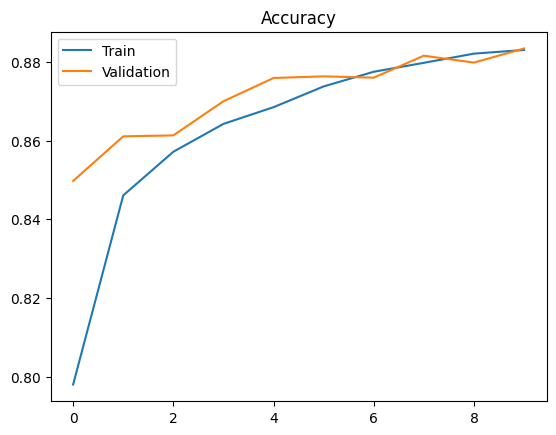

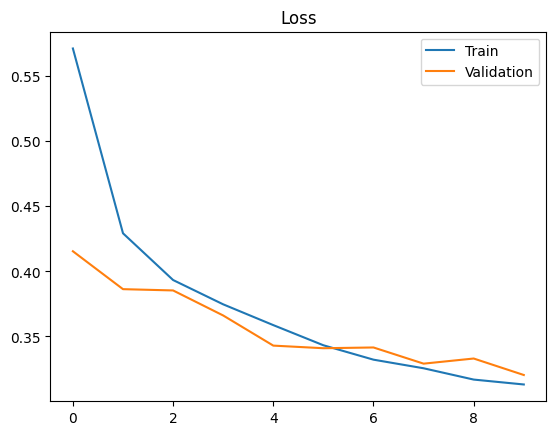

In [15]:
#5. Visualización de resultados
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [16]:
#6. Evaluación final
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Accuracy en test:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8732 - loss: 0.3478
Accuracy en test: 0.873199999332428


PARA VER HIPERPARAMETROS SE CREA UNA FUNCION DEL MODELO

In [17]:
#1. Crear una función para reutilizar modelo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

def crear_modelo(neuronas=128, dropout_rate=0.3):

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(neuronas, activation='relu'),
        Dropout(dropout_rate),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [18]:
#2. Probar distintos modelos
resultados = []

configuraciones = [
    (64, 0.2),
    (128, 0.3),
    (256, 0.4)
]

for neuronas, dropout in configuraciones:

    print(f"\nModelo: {neuronas} neuronas - Dropout {dropout}")

    model = crear_modelo(neuronas, dropout)

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    val_acc = history.history['val_accuracy'][-1]

    resultados.append((neuronas, dropout, val_acc))


Modelo: 64 neuronas - Dropout 0.2

Modelo: 128 neuronas - Dropout 0.3

Modelo: 256 neuronas - Dropout 0.4


In [19]:
#3. Mostrar resultados
for r in resultados:
    print(f"Neuronas: {r[0]} | Dropout: {r[1]} | Val Accuracy: {r[2]:.4f}")

import pandas as pd

df_resultados = pd.DataFrame(resultados, columns=['Neuronas','Dropout','Val_Accuracy'])
df_resultados

Neuronas: 64 | Dropout: 0.2 | Val Accuracy: 0.8799
Neuronas: 128 | Dropout: 0.3 | Val Accuracy: 0.8839
Neuronas: 256 | Dropout: 0.4 | Val Accuracy: 0.8852


,Neuronas,Dropout,Val_Accuracy
0,64,0.2,0.879917
1,128,0.3,0.883917
2,256,0.4,0.885250


● Lección 4: REDES NEURONALES CONVOLUTIVAS

📌 Objetivo: Integrar una red convolutiva para mejorar la capacidad predictiva del modelo.

📍 Tareas a desarrollar:

● Rediseñar la arquitectura utilizando CNN.

● Evaluar y comparar los resultados con el modelo anterior.

● Generar predicciones visuales sobre imágenes externas.

In [20]:
#1. Preprocesamiento para CNN
# Agregar dimensión de canal (blanco y negro = 1 canal)
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [21]:
#2. Definir arquitectura CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_cnn = Sequential([

    # 🔹 Capa convolucional (detecta patrones)
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),

    # 🔹 Reduce dimensión
    MaxPooling2D((2,2)),

    # 🔹 Segunda capa convolucional (patrones más complejos)
    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    # 🔹 Aplanar para conectar con capas densas
    Flatten(),

    # 🔹 Capa densa
    Dense(128, activation='relu'),

    # 🔹 Regularización
    Dropout(0.3),

    # 🔹 Salida
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
#3. Compilar modelo
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
#4. Entrenamiento
history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8029 - loss: 0.5395 - val_accuracy: 0.8712 - val_loss: 0.3545
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8719 - loss: 0.3556 - val_accuracy: 0.8885 - val_loss: 0.3035
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.8874 - loss: 0.3096 - val_accuracy: 0.8943 - val_loss: 0.2879
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8985 - loss: 0.2781 - val_accuracy: 0.9003 - val_loss: 0.2661
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9062 - loss: 0.2531 - val_accuracy: 0.9024 - val_loss: 0.2606
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9146 - loss: 0.2302 - val_accuracy: 0.9081 - val_loss: 0.2524
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9205 - loss: 0.2132 - val_accuracy: 0.9047 - val_loss: 0.2561
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9263 -

In [24]:
#5. Evaluación
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test_cnn, y_test)
print("Accuracy CNN:", test_acc_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9121 - loss: 0.2661
Accuracy CNN: 0.9121000170707703


In [25]:
#6. Comparación con modelo anterior
print("Modelo Denso:", test_acc)
print("Modelo CNN:", test_acc_cnn)

Modelo Denso: 0.873199999332428
Modelo CNN: 0.9121000170707703


In [ ]:
"""
El modelo basado en CNN obtuvo un mejor rendimiento en comparación con la red neuronal densa. Esto se debe a su capacidad para extraer características espaciales relevantes de las imágenes, como bordes y formas, lo que permite una mejor clasificación.
"""

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


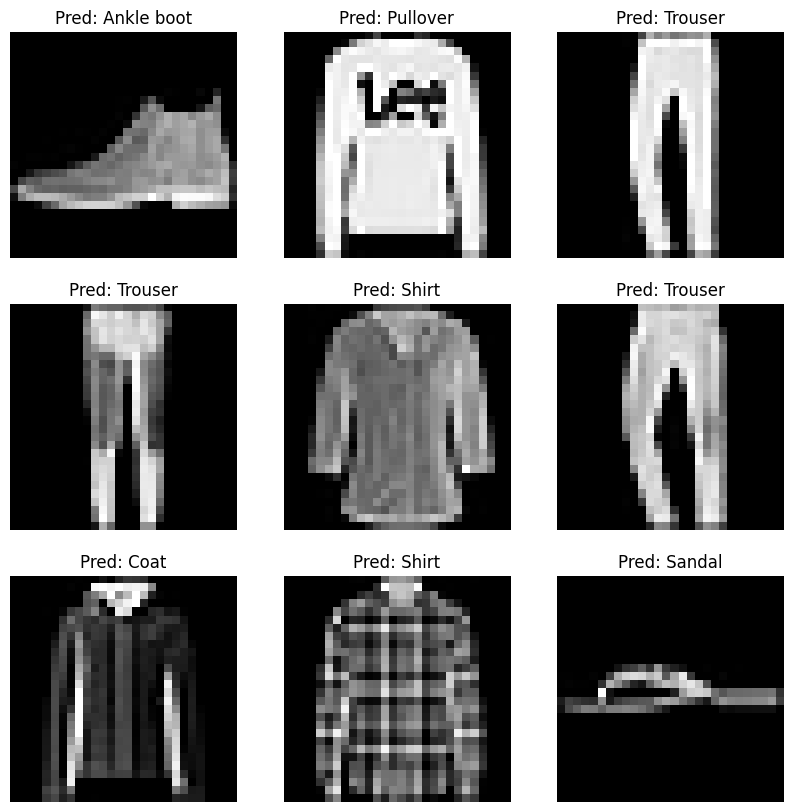

In [26]:
#7. Predicciones visuales
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Predicción
predicciones = model_cnn.predict(X_test_cnn[:9])

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i], cmap='gray')

    pred = np.argmax(predicciones[i])

    plt.title(f"Pred: {class_names[pred]}")
    plt.axis('off')

plt.show()

Conclusión (lista para pegar)

Se implementó una red neuronal convolutiva (CNN) que permitió mejorar significativamente el rendimiento del modelo en la clasificación de imágenes. A diferencia de la red densa, la CNN logra capturar patrones espaciales relevantes, lo que se traduce en una mayor precisión. Además, se visualizaron predicciones del modelo, demostrando su capacidad para clasificar correctamente nuevas imágenes.

In [27]:
#se se quiere cargar imagen externa adicional a la data:
#( se debe colocar el nombre a la imagen.jpg)

from tensorflow.keras.preprocessing import image

img = image.load_img('tu_imagen.jpg', target_size=(28,28), color_mode='grayscale')
img_array = image.img_to_array(img) / 255.0
img_array = img_array.reshape(1,28,28,1)

pred = model_cnn.predict(img_array)
print("Predicción:", class_names[np.argmax(pred)])